In [2]:
import os
print(os.getcwd())

c:\Users\Sameer\Downloads\mutual_fund_analytics\notebooks


In [3]:
import os

print(os.listdir())

['01_data_ingestion.ipynb', '02_data_cleaning.ipynb', '03_eda_analysis.ipynb', '04_performance_metrics.ipynb', '05_advanced_analytics.ipynb']


In [4]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
hold = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

print("NAV:", nav.shape)
print("PERF:", perf.shape)
print("TXN:", txn.shape)
print("HOLD:", hold.shape)

NAV: (46000, 3)
PERF: (40, 19)
TXN: (32778, 13)
HOLD: (322, 8)


In [5]:
# Daily returns

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

returns = nav.dropna(subset=['daily_return'])

# VaR and CVaR

var_cvar = []

for scheme in returns['amfi_code'].unique():

    r = returns[returns['amfi_code'] == scheme]['daily_return']

    var95 = np.percentile(r, 5)

    cvar95 = r[r <= var95].mean()

    var_cvar.append([
        scheme,
        var95,
        cvar95
    ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved")

var_cvar_report.csv saved


In [7]:
import os

os.makedirs("../reports", exist_ok=True)

var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [8]:
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

rolling_results = []

for scheme in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == scheme].copy()

    temp['rolling_sharpe'] = (
        temp['daily_return'].rolling(90).mean()
        /
        temp['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    temp['amfi_code'] = scheme

    rolling_results.append(
        temp[['date','amfi_code','rolling_sharpe']]
    )

rolling_sharpe_df = pd.concat(
    rolling_results,
    ignore_index=True
)

rolling_sharpe_df.head()

,date,amfi_code,rolling_sharpe
0,2022-01-03,100016,NaN
1,2022-01-04,100016,NaN
2,2022-01-05,100016,NaN
3,2022-01-06,100016,NaN
4,2022-01-07,100016,NaN


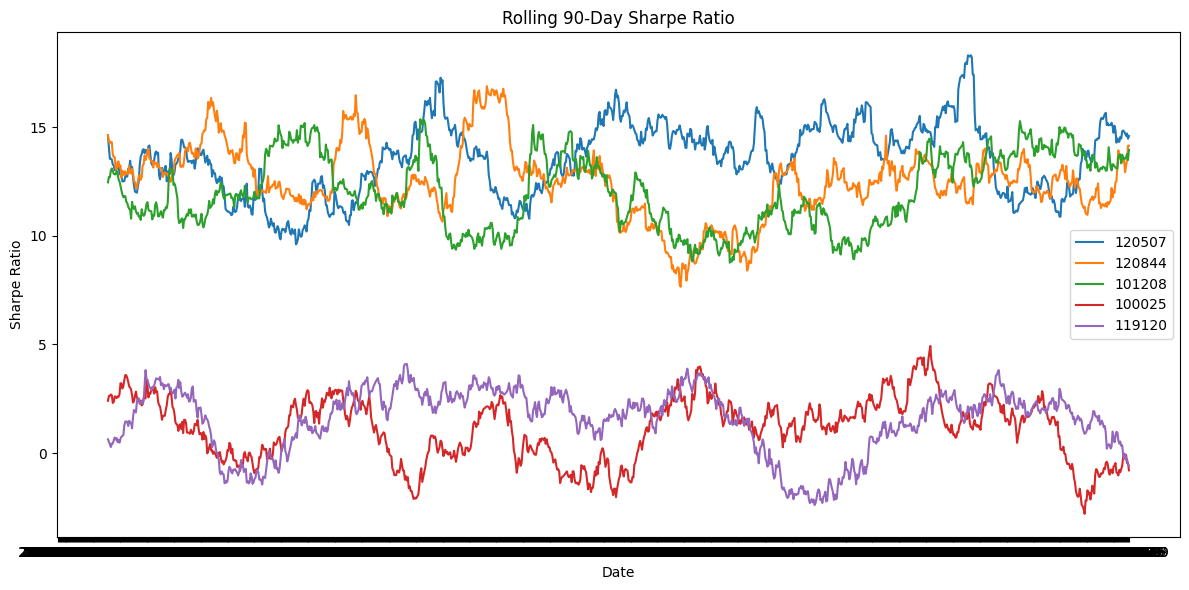

In [10]:
top5 = perf.sort_values(
    'sharpe_ratio',
    ascending=False
).head(5)

top5_codes = top5['amfi_code'].tolist()

plt.figure(figsize=(12,6))

for code in top5_codes:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [11]:
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

# First transaction year per investor
first_txn = (
    txn.groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = first_txn['transaction_date'].dt.year

# Merge back
cohort_df = txn.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id'
)

cohort_summary = (
    cohort_df.groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr', 'mean'),
        total_invested=('amount_inr', 'sum'),
        investors=('investor_id', 'nunique')
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [12]:
# Top fund preference per cohort

fund_pref = (
    cohort_df.groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='txn_count')
)

top_funds = (
    fund_pref.sort_values(
        ['cohort_year', 'txn_count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .head(1)
)

top_funds = top_funds.merge(
    perf[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

top_funds[['cohort_year', 'scheme_name', 'txn_count']]

,cohort_year,scheme_name,txn_count
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,SBI Small Cap Fund - Direct Plan - Growth,12


In [13]:
# SIP transactions only

sip_txn = txn[
    txn['transaction_type']
    .str.upper()
    .str.contains('SIP', na=False)
].copy()

# Sort

sip_txn = sip_txn.sort_values(
    ['investor_id', 'transaction_date']
)

# Gap calculation

sip_txn['gap_days'] = (
    sip_txn.groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

# Investors with 6+ SIP transactions

sip_counts = (
    sip_txn.groupby('investor_id')
    .size()
    .reset_index(name='sip_count')
)

eligible = sip_counts[
    sip_counts['sip_count'] >= 6
]

sip_analysis = sip_txn.merge(
    eligible[['investor_id']],
    on='investor_id'
)

continuity = (
    sip_analysis.groupby('investor_id')
    .agg(
        avg_gap_days=('gap_days','mean'),
        sip_transactions=('gap_days','count')
    )
    .reset_index()
)

continuity['status'] = np.where(
    continuity['avg_gap_days'] > 35,
    'At-Risk',
    'Healthy'
)

continuity.head()

,investor_id,avg_gap_days,sip_transactions,status
0,INV000004,85.400000,5,At-Risk
1,INV000008,70.400000,5,At-Risk
2,INV000010,64.800000,5,At-Risk
3,INV000011,40.166667,6,At-Risk
4,INV000012,57.000000,7,At-Risk


In [14]:
continuity['status'].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

In [15]:
def recommend_funds(risk_level):

    risk_map = {
        "Low": ["Low", "Moderate"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High"]
    }

    filtered = perf[
        perf['risk_grade'].isin(risk_map[risk_level])
    ]

    recommendations = (
        filtered.sort_values(
            'sharpe_ratio',
            ascending=False
        )
        [['scheme_name','risk_grade','sharpe_ratio']]
        .head(3)
    )

    return recommendations


recommend_funds("Moderate")

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [16]:
hhi = (
    hold.groupby('amfi_code')['weight_pct']
    .apply(lambda x: ((x/100)**2).sum())
    .reset_index(name='HHI')
)

hhi = hhi.merge(
    perf[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

hhi.sort_values(
    'HHI',
    ascending=False
).head()

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth


In [17]:
highest_var = var_cvar_df.sort_values(
    'VaR_95'
).head(1)

highest_cvar = var_cvar_df.sort_values(
    'CVaR_95'
).head(1)

highest_hhi = hhi.sort_values(
    'HHI',
    ascending=False
).head(1)

print(highest_var)
print(highest_cvar)
print(highest_hhi)

    amfi_code    VaR_95   CVaR_95
22     119599 -0.026859 -0.032384
   amfi_code    VaR_95   CVaR_95
4     101207 -0.026021 -0.032459
    amfi_code       HHI                            scheme_name
11     119092  0.206448  Axis Bluechip Fund - Regular - Growth


# Advanced Insights

## 1. Highest Downside Risk
Fund AMFI 119599 recorded the most negative VaR (95%) value of -2.69%, indicating the highest expected loss under normal market conditions among all schemes.

## 2. Highest Tail Risk
Fund AMFI 101207 showed the lowest CVaR value of -3.25%, meaning extreme losses beyond the VaR threshold are more severe for this scheme.

## 3. Investor Cohort Dominance
The 2024 investor cohort contributed the majority of investments, with over 4,800 investors and significantly higher total invested capital than the 2025 cohort.

## 4. SIP Continuity Concern
More than 1,300 investors were classified as At-Risk due to average SIP gaps exceeding 35 days, indicating potential discontinuation risk.

## 5. Portfolio Concentration
Axis Bluechip Fund - Regular - Growth recorded the highest HHI score (0.2064), indicating a relatively concentrated portfolio compared with other schemes.